# Product Recommendation System

## Import Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

## Data Collection

In [2]:
df = pd.read_csv("data/raw_data.csv",encoding='latin1')
display(df.head(5))
display(df.info())
display(df.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Preprocessing

In [3]:
df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df = df[~df['InvoiceNo'].str.contains('C', na=False)]
df["CustomerID"] = df["CustomerID"].astype(int)


upper_qty  = df["Quantity"].quantile(0.99)
df = df[(df["Quantity"] <= upper_qty)]

upper_price  = df["UnitPrice"].quantile(0.99)
df = df[(df["UnitPrice"] <= upper_price)]

## Feature Engineering 

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [19]:
df.to_csv("data/cleaned_data.csv")

## Data Visualization 

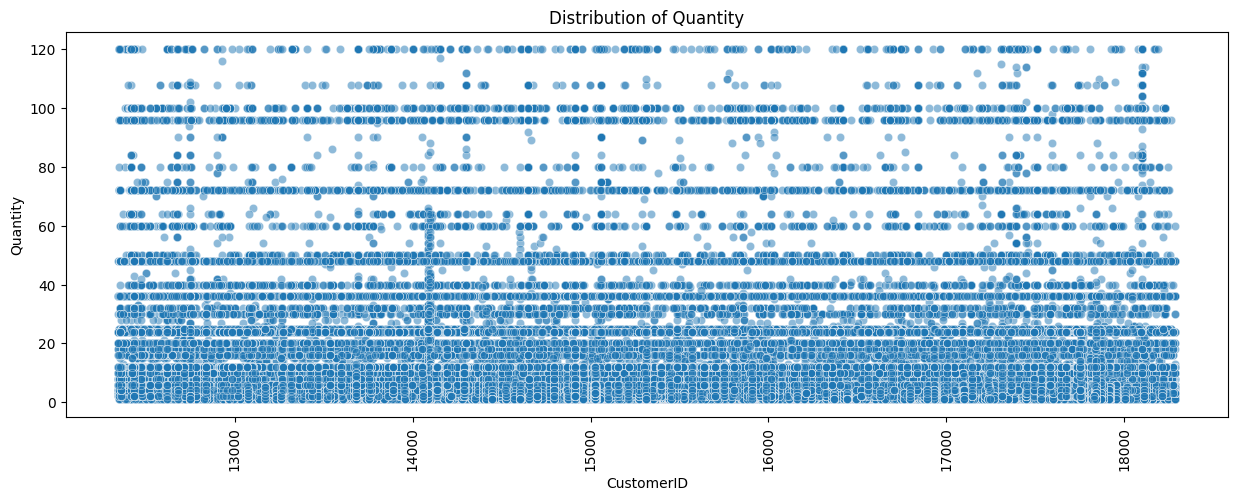

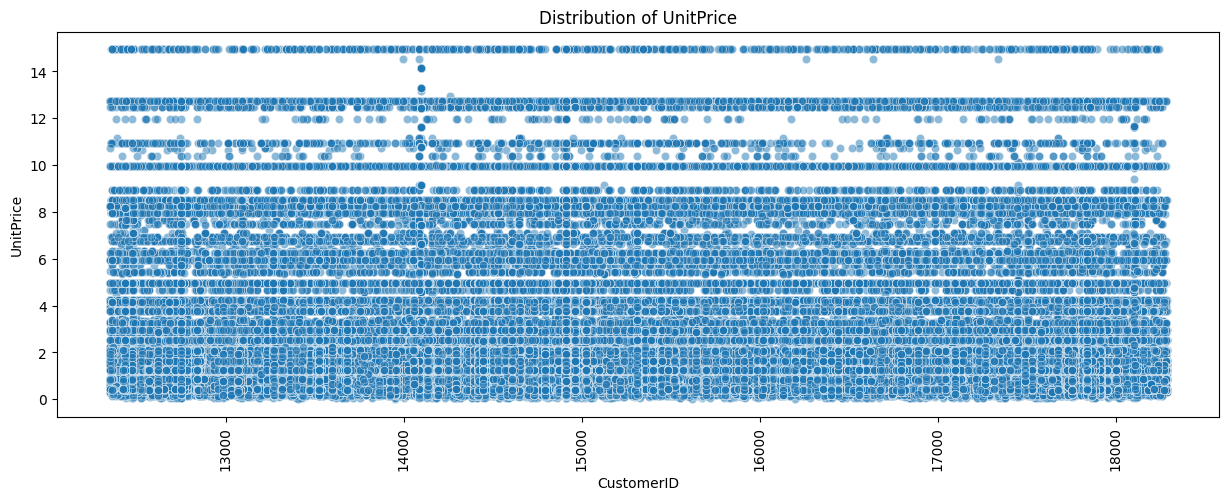

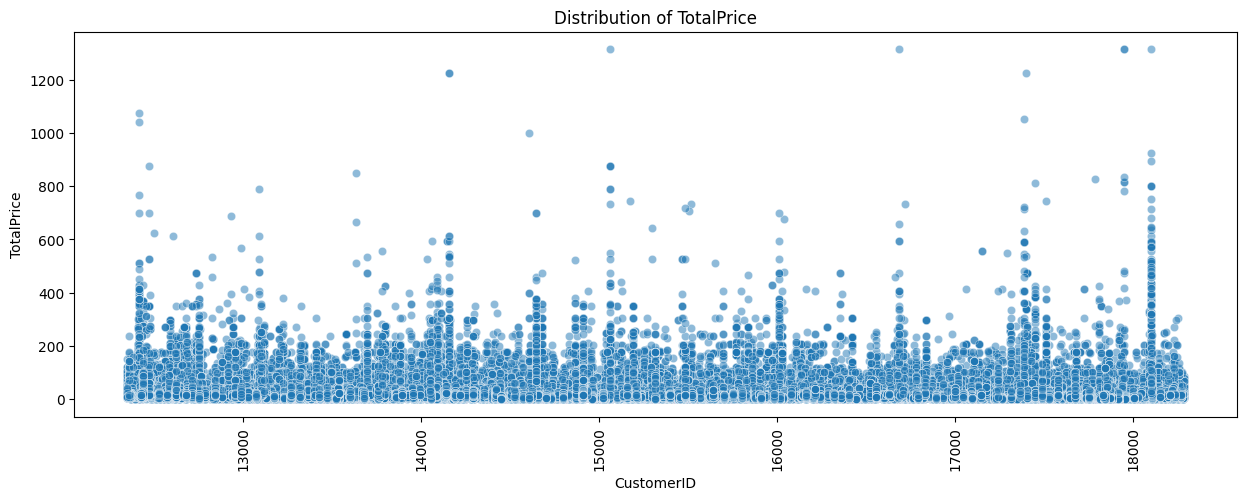

In [5]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

### UNIVARIATE ANALYSIS
for col in num_cols:
    plt.figure(figsize=(15,5))
    sns.scatterplot(data=df, x="CustomerID", y=col, alpha=0.5)
    plt.xticks(rotation=90)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'static/Distribution of {col}')
    plt.show()

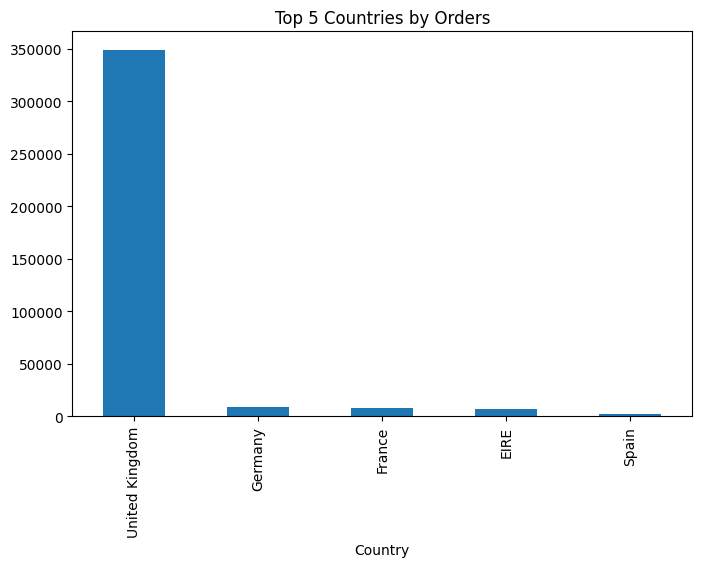

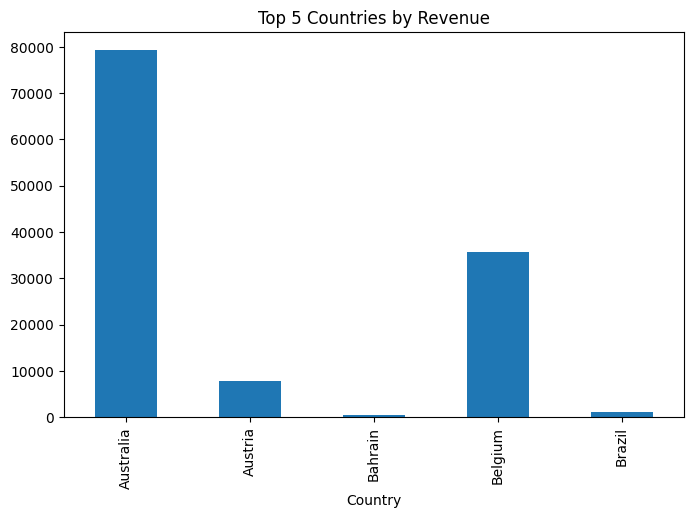

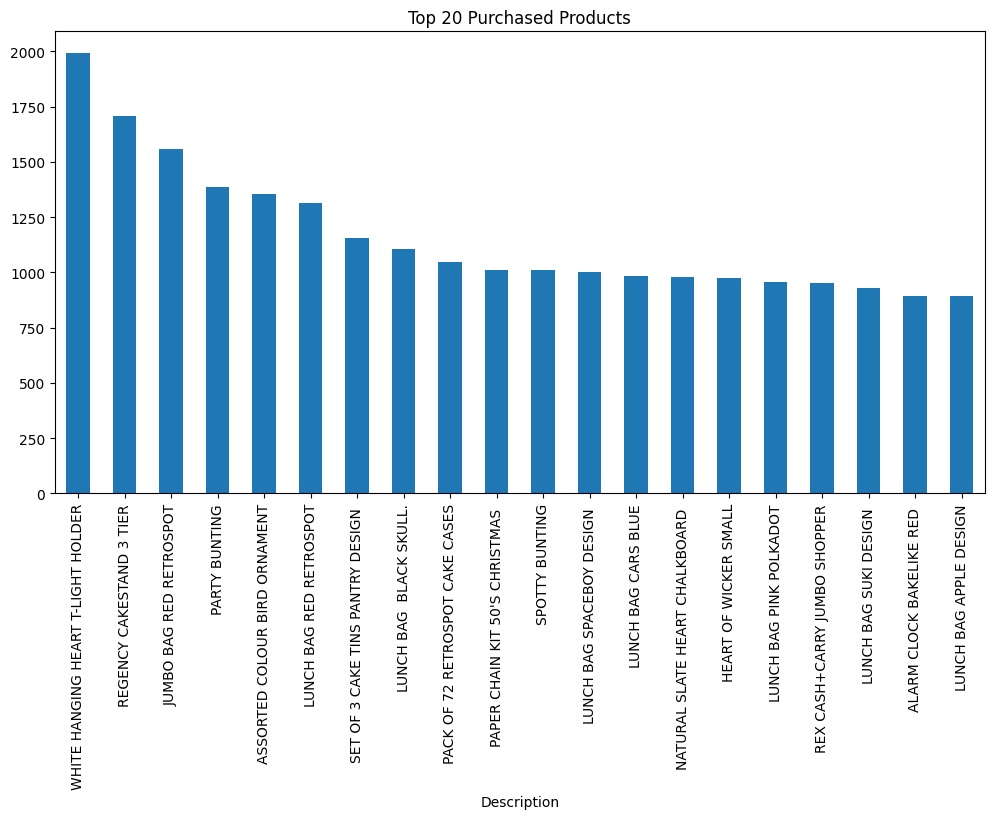

In [6]:
# Top Countries by Orders
plt.figure(figsize=(8,5))
df['Country'].value_counts().head(5).plot(kind='bar')
plt.title('Top 5 Countries by Orders')
plt.savefig(f'static/Top 5 Countries by Orders')
plt.show()

# Top Countries by Revenue
plt.figure(figsize=(8,5))
df.groupby('Country')['TotalPrice'].sum().head(5).plot(kind='bar')
plt.title('Top 5 Countries by Revenue')
plt.savefig(f'static/Top 5 Countries by Revenue')
plt.show()

# Top Products
plt.figure(figsize=(12,6))
df['Description'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Purchased Products')
plt.savefig(f'static/Top 20 Purchased Products')
plt.show()

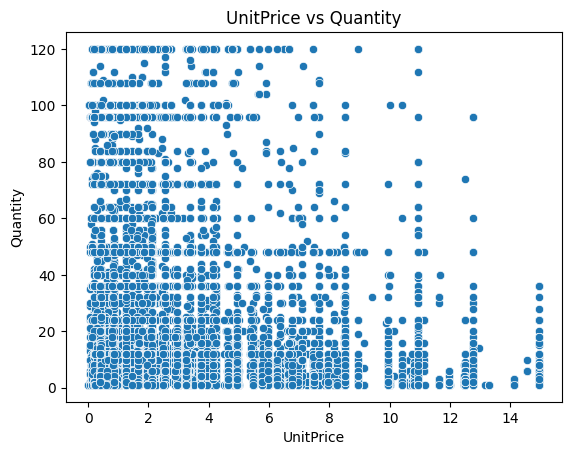

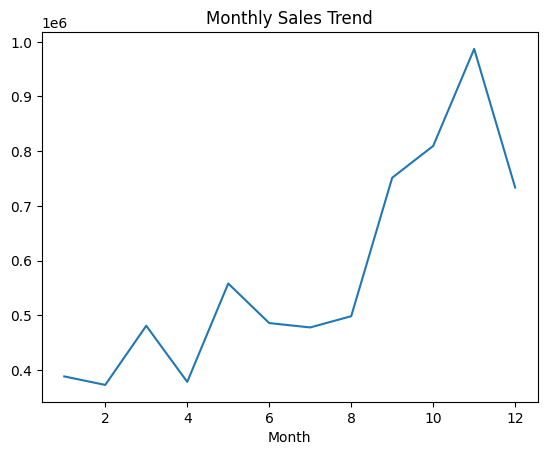

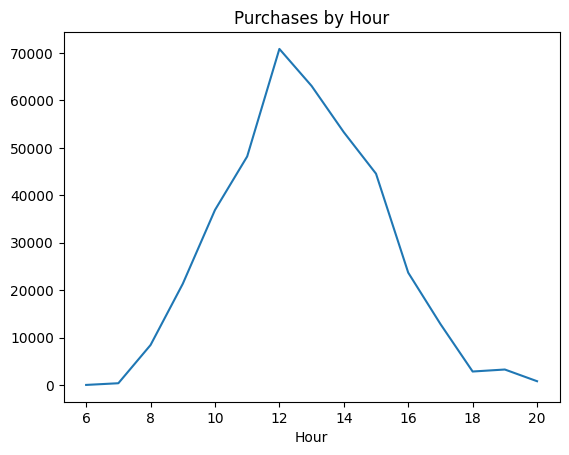

In [7]:
### MULTIVARIATE ANALYSIS

# Quantity vs Price
plt.figure()
sns.scatterplot(x='UnitPrice', y='Quantity', data=df)
plt.title('UnitPrice vs Quantity')
plt.savefig(f'static/Quantity vs Price')
plt.show()

# Monthly Sales Trend
monthly_sales = (df.groupby('Month')['TotalPrice'].sum())
plt.figure()
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.savefig(f'static/Monthly Sales Trend')
plt.show()

# Hourly Purchase Trend
hour_sales = (df.groupby('Hour')['InvoiceNo'].count())
plt.figure()
hour_sales.plot()
plt.title('Purchases by Hour')
plt.savefig(f'static/Purchases by Hour')
plt.show()

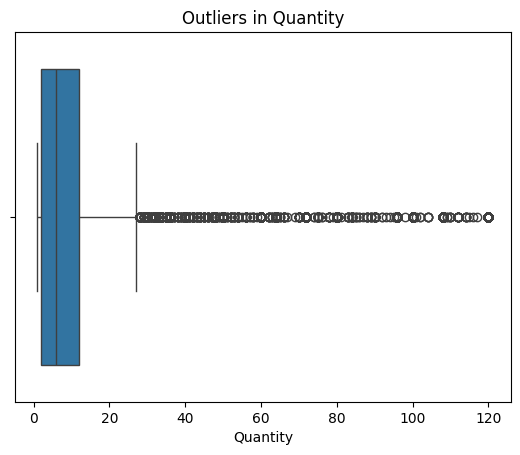

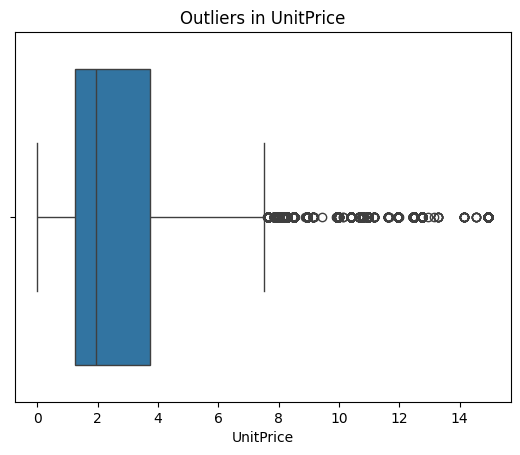

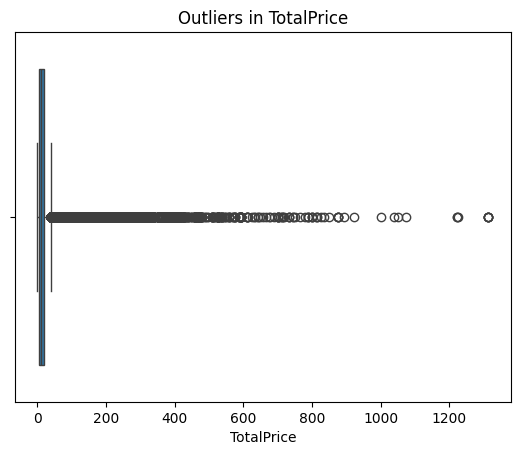

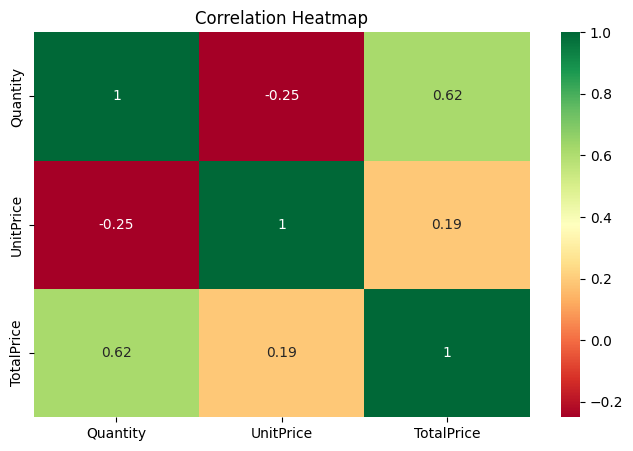

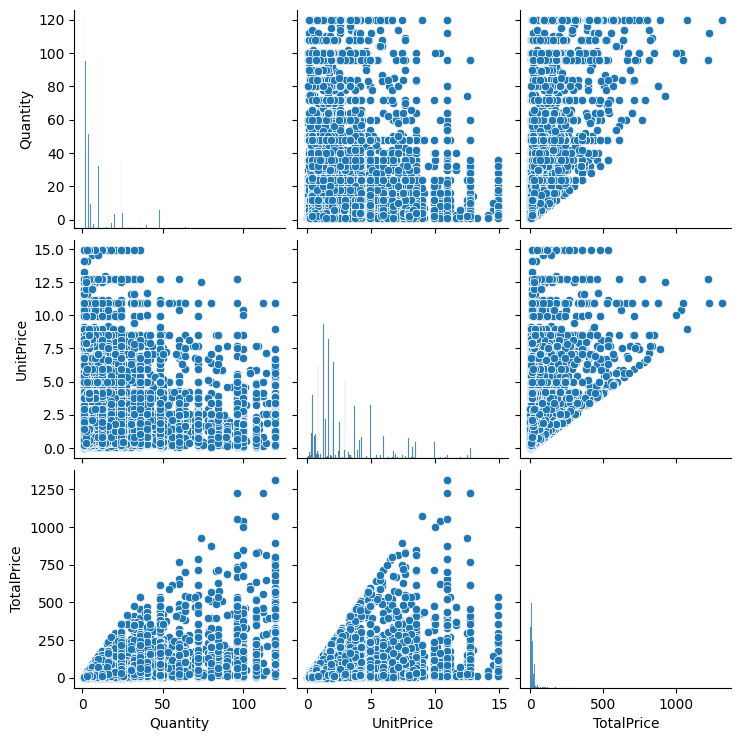

In [10]:
### OUTLIER DETECTION
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.savefig(f'static/Outliers in {col}')
    plt.show()

### CORRELATION MATRIX
plt.figure(figsize=(8,5))
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.savefig(f'static/Correlation Heatmap')
plt.show()


# Pairplot
sns.pairplot(df[['Quantity', 'UnitPrice', 'TotalPrice']])
plt.savefig(f'static/PairPlot')
plt.show()

In [11]:
## Sparsity of Dataset
n_customers = df.CustomerID.nunique()
n_products = df.Description.nunique()
sparsity = (1 - len(df) / (n_customers * n_products))

print("Unique Users :", n_customers)
print("Unique Products :", n_products)
print(f"{sparsity * 100:.2f}% of user-item matrix is empty and only about {100 - (sparsity * 100):.2f}% of all possible user-item interactions are present.")

## Train Test Split
df = df.sort_values("InvoiceDate")
train_size = int(len(df) * 0.80)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(train_df.shape)
print(test_df.shape)

Unique Users : 4290
Unique Products : 3832
97.63% of user-item matrix is empty and only about 2.37% of all possible user-item interactions are present.
(312208, 12)
(78052, 12)


## Model Training

In [12]:
### Popularity Recommendation
popular_products = (
    train_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

def popularity_recommend(n = 5):
    return popular_products[:n]

In [13]:
### Collaborative Recommendation
# User Item Matrix 
user_item = train_df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

user_similarity = cosine_similarity(user_item)
item_similarity = cosine_similarity(user_item.T)
user_similarity_df = pd.DataFrame(user_similarity, index = user_item.index, columns = user_item.index)
item_similarity_df = pd.DataFrame(item_similarity, index = user_item.columns, columns = user_item.columns)


def user_based_recommend(customer_id, top_n = 5):
    if customer_id not in user_item.index:
        return []

    similar_users = (
        user_similarity_df[customer_id]
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
    )

    purchased = (user_item.loc[customer_id])
    purchased = (purchased[purchased > 0].index)

    scores = {}
    for user in similar_users:
        items = user_item.loc[user]
        for product in items[items > 0].index:
            if product not in purchased:
                scores[product] = (scores.get(product, 0) + items[product])

    scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [x[0] for x in scores[:top_n]]


def item_based_recommend(product, top_n = 5):
    if product not in item_similarity_df.index:
        return []

    return (
        item_similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )

In [14]:
### Content Based Recommendation
product_data = (train_df[['Description']].drop_duplicates().reset_index(drop=True))
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(product_data['Description'])
content_similarity = cosine_similarity(tfidf_matrix)

content_similarity_df = pd.DataFrame(
    content_similarity,
    index=product_data['Description'],
    columns=product_data['Description']
)

def content_recommend(product, top_n = 5):
    if product not in content_similarity_df.index:
        return []

    return (
        content_similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )

In [15]:
### Hybrid Recommendation
def hybrid_recommend(product, top_n = 5):
    
    if (product not in item_similarity_df.index or product not in content_similarity_df.index):
        return []

    hybrid_score = (item_similarity_df[product] * 0.6 + content_similarity_df[product] * 0.4)

    return (
        hybrid_score
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )

## Model Evaluation

In [18]:
ground_truth = (
    test_df
    .groupby("CustomerID")["Description"]
    .apply(set)
    .to_dict()
)

K = 5
popularity_dict = {}
user_cf_dict = {}
item_cf_dict = {}
content_dict = {}
hybrid_dict = {}

for user in ground_truth.keys():
    popularity_dict[user] = (popularity_recommend(K))

    if user not in user_item.index:
        continue

    user_cf_dict[user] = (user_based_recommend(user, K))
    purchased = (user_item.loc[user])

    purchased = (
        purchased[purchased > 0]
        .index
        .tolist()
    )

    item_recs = []
    content_recs = []
    hybrid_recs = []

    for product in purchased[:3]:

        item_recs.extend(item_based_recommend(product, K))
        content_recs.extend(content_recommend(product, K))
        hybrid_recs.extend(hybrid_recommend(product, K))

    item_cf_dict[user] = (list(dict.fromkeys(item_recs))[:K])
    content_dict[user] = (list(dict.fromkeys(content_recs))[:K])
    hybrid_dict[user] = (list(dict.fromkeys(hybrid_recs))[:K])


# Performance Metrics 

test_user_items = (
    test_df.groupby("CustomerID")["Description"]
    .apply(set)
    .to_dict()
)
all_products = set(df["Description"].unique())

def precision_at_k(recommended, relevant, k = 5):
    recommended = recommended[:k]
    if len(recommended) == 0:
        return 0

    hits = len(set(recommended) & set(relevant))
    return hits / len(recommended)


def recall_at_k(recommended, relevant, k = 5):
    recommended = recommended[:k]
    if len(relevant) == 0:
        return 0

    hits = len(set(recommended) & set(relevant))
    return hits / len(relevant)


def f1_at_k(recommended, relevant, k = 5):
    p = precision_at_k(recommended, relevant, k)
    r = recall_at_k(recommended, relevant, k)

    if p + r == 0:
        return 0

    return 2 * p * r / (p + r)


def hit_rate_at_k(recommended, relevant, k = 5):
    recommended = recommended[:k]
    return int(len(set(recommended) & set(relevant)) > 0)


def average_precision(recommended, relevant, k = 5):
    score = 0
    hits = 0

    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / i

    if hits == 0:
        return 0

    return score / min(len(relevant), k)


def map_at_k(all_recommendations, ground_truth, k = 5):
    scores = []
    for user, recs in all_recommendations.items():
        if user in ground_truth:
            ap = average_precision(recs, ground_truth[user], k)
            scores.append(ap)

    return np.mean(scores)


def ndcg_at_k(recommended, relevant, k = 5):
    dcg = 0
    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1 / np.log2(i + 1)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    if idcg == 0:
        return 0

    return dcg / idcg


def coverage(all_recommendations):
    recommended_items = set()
    for recs in all_recommendations.values():
        recommended_items.update(recs)

    return (len(recommended_items) / len(all_products))


def diversity(recommended_items, similarity_matrix):
    if len(recommended_items) < 2:
        return 0

    distances = []
    for i in range(len(recommended_items)):
        for j in range(i+1, len(recommended_items)):

            item1 = recommended_items[i]
            item2 = recommended_items[j]
            sim = similarity_matrix.loc[item1, item2]

            distances.append(1 - sim)

    return np.mean(distances)


def personalization(all_recommendations):
    users = list(all_recommendations.keys())
    similarities = []

    for i in range(len(users)):
        for j in range(i+1, len(users)):

            rec1 = set(all_recommendations[users[i]])
            rec2 = set(all_recommendations[users[j]])
            union = len(rec1 | rec2)

            if union == 0:
                continue

            sim = len(rec1 & rec2) / union
            similarities.append(sim)

    if len(similarities) == 0:
        return 0

    return 1 - np.mean(similarities)

def evaluate_model(name, recommendations):
    precisions = []
    recalls = []
    f1s = []
    hits = []
    ndcgs = []


    for user,recs in recommendations.items():

        if user not in ground_truth:
            continue

        relevant = ground_truth[user]

        precisions.append(precision_at_k(recs, relevant, K))
        recalls.append(recall_at_k(recs, relevant, K))
        f1s.append(f1_at_k(recs, relevant, K))
        hits.append(hit_rate_at_k(recs, relevant, K))
        ndcgs.append(ndcg_at_k(recs, relevant, K))

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(f"Precision@5     : {np.mean(precisions) * 100:.2f}%")
    print(f"Recall@5        : {np.mean(recalls) * 100:.2f}%")
    print(f"F1@5            : {np.mean(f1s) * 100:.2f}%")
    print(f"HitRate@5       : {np.mean(hits) * 100:.2f}%")
    print(f"MAP@5           : {map_at_k(recommendations, ground_truth, K) * 100:.2f}")
    print(f"NDCG@5          : {np.mean(ndcgs) * 100:.2f}%")
    print(f"Coverage        : {coverage(recommendations) * 100:.2f}")
    print(f"Personalization : {personalization(recommendations) * 100:.2f}%")



evaluate_model("Popularity", popularity_dict)
evaluate_model("User CF", user_cf_dict)
evaluate_model("Item CF", item_cf_dict)
evaluate_model("Content Based", content_dict)
evaluate_model("Hybrid", hybrid_dict)


Popularity
Precision@5     : 8.23%
Recall@5        : 1.79%
F1@5            : 2.38%
HitRate@5       : 32.23%
MAP@5           : 4.79
NDCG@5          : 8.71%
Coverage        : 0.13
Personalization : 0.00%

User CF
Precision@5     : 3.55%
Recall@5        : 0.74%
F1@5            : 1.08%
HitRate@5       : 14.67%
MAP@5           : 2.01
NDCG@5          : 3.75%
Coverage        : 30.74
Personalization : 99.31%

Item CF
Precision@5     : 3.68%
Recall@5        : 1.06%
F1@5            : 1.31%
HitRate@5       : 12.88%
MAP@5           : 2.65
NDCG@5          : 4.32%
Coverage        : 24.35
Personalization : 98.15%

Content Based
Precision@5     : 4.79%
Recall@5        : 1.26%
F1@5            : 1.62%
HitRate@5       : 17.86%
MAP@5           : 2.92
NDCG@5          : 5.09%
Coverage        : 25.29
Personalization : 97.98%

Hybrid
Precision@5     : 5.41%
Recall@5        : 1.46%
F1@5            : 1.87%
HitRate@5       : 18.13%
MAP@5           : 3.66
NDCG@5          : 6.03%
Coverage        : 26.41
Personali

## Model Deployment

In [17]:
item_similarity_df.index = item_similarity_df.index.astype(object)
item_similarity_df.columns = item_similarity_df.columns.astype(object)

content_similarity_df.index = content_similarity_df.index.astype(object)
content_similarity_df.columns = content_similarity_df.columns.astype(object)

hybrid_model = {"item_similarity": item_similarity_df, "content_similarity": content_similarity_df, "item_weight": 0.6, "content_weight": 0.4}


joblib.dump(popular_products, "models/model_popular.pkl")
joblib.dump(user_item, "models/model_user_item.pkl")
joblib.dump(user_similarity_df, "models/model_cf_user.pkl")
joblib.dump(item_similarity_df, "models/model_cf_item.pkl")
joblib.dump(content_similarity_df, "models/model_content.pkl")
joblib.dump(hybrid_model, "models/model_hybrid.pkl")
print("\n All Models Saved")


 All Models Saved
